In [1]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
from probeinterface import write_probeinterface, read_probeinterface
import spikeinterface.exporters as sexp
from spikeinterface.core import write_binary_recording
from pathlib import Path
import pickle
from tabnanny import verbose
import spikeinterface as si
import numpy as np
from spikeinterface.core import get_template_extremum_channel
import scipy.spatial.distance
from scipy.sparse.csgraph import connected_components
import pickle
import pandas as pd
from scipy.io import loadmat

probe_data = loadmat("/media/ubuntu/sda/duan/raw_data/chanMap_DCX_5mm.mat")
probe_x = probe_data['xcoords']
probe_y = probe_data['ycoords']

probe_position = pd.DataFrame(probe_x)
probe_position[1] = probe_y
probe_position['chan_map'] = probe_data['chanMap0ind'].astype(int)

chan_map = pd.read_csv('/media/ubuntu/sda/duan/raw_data/ch_map_R.csv')
merged = chan_map.merge(probe_position, left_on='probeloc', right_on='chan_map')\
                 .iloc[chan_map.index]\
                 .reset_index(drop=True)

probe = Probe()
probe.set_contacts(positions=merged.iloc[:, 2:4])
probe.set_device_channel_indices(range(256))


/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
recording_raw = se.read_intan(f"/home/ubuntu/Downloads/M190011_260311_125012_merged_130.rhd", stream_id= '0', ignore_integrity_checks=True)

print('read success')

recording_raw = spre.unsigned_to_signed(recording_raw)
recording_raw = spre.resample(recording_raw, 10000)

recording_recorded = spre.bandpass_filter(recording_raw, freq_min=300, freq_max=3000)
recording_recorded = spre.notch_filter(recording_recorded, freq=50)
recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

recording_f = recording_f.set_probegroup(probe)

recording_preprocessed = recording_f.save(format="binary", n_jobs=30)

read success
Use cache_folder=/tmp/spikeinterface_cache/tmporl0xtpy/200OBR9J
write_binary_recording 
engine=process - n_jobs=30 - samples_per_chunk=10,000 - chunk_memory=4.88 MiB - total_memory=146.48 MiB - chunk_duration=1.00s


write_binary_recording (workers: 30 processes): 100%|██████████| 7068/7068 [07:16<00:00, 16.18it/s]


In [16]:
# output_dir = '/media/ubuntu/sda/duan/result/260311'

# sampling_frequency = recording_preprocessed.get_sampling_frequency()
# phy_folder = f'{output_dir}/phy_folder_for_kilosort'

# print("读取统一的sorting结果...")
# sorting_curated_phy = se.read_phy(phy_folder, exclude_cluster_groups=["noise"])
# print(f"读取到 {len(sorting_curated_phy.unit_ids)} 个units\n")

# print("创建analyzer并计算extensions...")
# analyzer_curated_phy = si.create_sorting_analyzer(
#     sorting=sorting_curated_phy, 
#     recording=recording_preprocessed,  # 使用common reference后的recording
#     format='binary_folder',
#     folder=output_dir + '/analyzer_curated_temp',
#     n_jobs=20, verbose = False
# )

# extensions_to_compute = [
#     "random_spikes",
#     "waveforms",
#     "templates",
#     "unit_locations",
#     "template_similarity"
# ]

# extension_params = {
#     "unit_locations": {"method": "center_of_mass"},
#     "template_similarity": {"method": "cosine_similarity"}
# }

# analyzer_curated_phy.compute(extensions_to_compute, extension_params=extension_params, n_jobs=20, verbose = False)
# print("完成extensions计算\n")

# # 获取neuron信息（整个recording）
# templates_ext = analyzer_curated_phy.get_extension("templates")
# templates_dense = templates_ext.data["average"]
# sparsity = analyzer_curated_phy.sparsity
# unit_locations_ext = analyzer_curated_phy.get_extension("unit_locations")
# unit_locations = unit_locations_ext.get_data()
# channel_locations = analyzer_curated_phy.get_channel_locations()

# # 处理merge逻辑
# if unit_locations.shape[1] >= 2:
#     unit_distances = scipy.spatial.distance.cdist(
#         unit_locations[:, :2], 
#         unit_locations[:, :2], 
#         metric="euclidean"
#     )
# else:
#     unit_distances = scipy.spatial.distance.cdist(
#         unit_locations, 
#         unit_locations, 
#         metric="euclidean"
#     )

# template_similarity_ext = analyzer_curated_phy.get_extension("template_similarity")
# template_similarity = template_similarity_ext.get_data()

# distance_threshold = 10.0
# similarity_threshold = 0.95
# num_units = len(analyzer_curated_phy.unit_ids)
# pair_mask = np.zeros((num_units, num_units), dtype=bool)

# for i in range(num_units):
#     for j in range(i + 1, num_units):
#         if unit_distances[i, j] < distance_threshold and template_similarity[i, j] > similarity_threshold:
#             pair_mask[i, j] = True
#             pair_mask[j, i] = True

# n_components, labels = connected_components(
#     csgraph=pair_mask, 
#     directed=False, 
#     return_labels=True
# )

# merge_unit_groups = []
# unit_ids_list = analyzer_curated_phy.unit_ids
# for component_id in range(n_components):
#     unit_indices = np.where(labels == component_id)[0]
#     if len(unit_indices) > 1:
#         group = [unit_ids_list[i] for i in unit_indices]
#         merge_unit_groups.append(group)

# if len(merge_unit_groups) > 0:
#     print(f"发现 {len(merge_unit_groups)} 组需要merge的units，开始merge...")
#     analyzer_merged = analyzer_curated_phy.merge_units(
#         merge_unit_groups=merge_unit_groups,
#         censor_ms=0.3,
#         merging_mode="hard",
#         new_id_strategy="append",
#         format='binary_folder',
#         folder=output_dir + '/analyzer_merged',
#         verbose=True,
#         n_jobs=20
#     )
    
#     analyzer_merged.compute(extensions_to_compute, extension_params=extension_params, n_jobs=20, verbose = False)
    
#     templates_ext_final = analyzer_merged.get_extension("templates")
#     templates_dense_final = templates_ext_final.data["average"]
#     sparsity_final = analyzer_merged.sparsity
#     unit_locations_ext_final = analyzer_merged.get_extension("unit_locations")
#     unit_locations_final = unit_locations_ext_final.get_data()
#     channel_locations_final = analyzer_merged.get_channel_locations()
#     sorting_final = analyzer_merged.sorting
#     unit_ids_list_final = analyzer_merged.unit_ids
    
#     # 生成position_waveforms
#     position_waveforms_final = []
#     for unit_id in unit_ids_list_final:
#         unit_index = analyzer_merged.sorting.id_to_index(unit_id)
#         template_dense_unit = templates_dense_final[unit_index, :, :]
#         template_sparse_unit = sparsity_final.sparsify_waveforms(template_dense_unit[np.newaxis, :, :], unit_id)[0]
#         sparse_channel_indices = sparsity_final.unit_id_to_channel_indices[unit_id]
        
#         if len(sparse_channel_indices) == 0:
#             position_waveform = np.zeros(templates_dense_final.shape[1], dtype=templates_dense_final.dtype)
#             position_waveforms_final.append(position_waveform)
#             continue
        
#         sparse_channel_locations = channel_locations_final[sparse_channel_indices, :2]
#         unit_location = unit_locations_final[unit_index, :2]
        
#         distances = np.sqrt(np.sum((sparse_channel_locations - unit_location[np.newaxis, :])**2, axis=1))
#         epsilon = 1e-10
#         weights = 1.0 / (distances + epsilon)
#         weights = weights / np.sum(weights)
        
#         position_waveform = np.dot(template_sparse_unit, weights)
#         position_waveforms_final.append(position_waveform)
    
#     position_waveforms_final = np.array(position_waveforms_final)
#     extremum_channels_final = get_template_extremum_channel(
#         analyzer_merged, 
#         peak_sign="neg",
#         outputs="id"
#     )
    
#     channel_ids_list = list(analyzer_merged.recording.get_channel_ids())
# else:
#     print("无需merge units\n")
#     templates_ext_final = analyzer_curated_phy.get_extension("templates")
#     templates_dense_final = templates_ext_final.data["average"]
#     sparsity_final = analyzer_curated_phy.sparsity
#     unit_locations_ext_final = analyzer_curated_phy.get_extension("unit_locations")
#     unit_locations_final = unit_locations_ext_final.get_data()
#     channel_locations_final = analyzer_curated_phy.get_channel_locations()
#     sorting_final = analyzer_curated_phy.sorting
#     unit_ids_list_final = unit_ids_list
    
#     # 生成position_waveforms
#     position_waveforms_final = []
#     for unit_id in unit_ids_list_final:
#         unit_index = analyzer_curated_phy.sorting.id_to_index(unit_id)
#         template_dense_unit = templates_dense_final[unit_index, :, :]
#         template_sparse_unit = sparsity_final.sparsify_waveforms(template_dense_unit[np.newaxis, :, :], unit_id)[0]
#         sparse_channel_indices = sparsity_final.unit_id_to_channel_indices[unit_id]
        
#         if len(sparse_channel_indices) == 0:
#             position_waveform = np.zeros(templates_dense_final.shape[1], dtype=templates_dense_final.dtype)
#             position_waveforms_final.append(position_waveform)
#             continue
        
#         sparse_channel_locations = channel_locations_final[sparse_channel_indices, :2]
#         unit_location = unit_locations_final[unit_index, :2]
        
#         distances = np.sqrt(np.sum((sparse_channel_locations - unit_location[np.newaxis, :])**2, axis=1))
#         epsilon = 1e-10
#         weights = 1.0 / (distances + epsilon)
#         weights = weights / np.sum(weights)
        
#         position_waveform = np.dot(template_sparse_unit, weights)
#         position_waveforms_final.append(position_waveform)
    
#     position_waveforms_final = np.array(position_waveforms_final)
#     extremum_channels_final = get_template_extremum_channel(
#         analyzer_curated_phy, 
#         peak_sign="neg",
#         outputs="id"
#     )
    
#     channel_ids_list = list(analyzer_curated_phy.recording.get_channel_ids())

# print("计算每个unit的channel_id...")
# channel_ids_dict = {} 
# for idx, unit_id in enumerate(unit_ids_list_final):
#     unit_index = sorting_final.id_to_index(unit_id)
#     template_unit = templates_dense_final[unit_index, :, :]  # (n_samples, n_channels)

#     non_zero_channels = []
#     for ch_idx in range(template_unit.shape[1]):  # 遍历channels（最后一个维度）
#         if np.any(template_unit[:, ch_idx] != 0):  # 检查该通道在所有时间点的值
#             # recording的channel_id已经是contact_id，直接使用
#             contact_id = str(channel_ids_list[ch_idx])
#             non_zero_channels.append(contact_id)
    
#     channel_ids_dict[unit_id] = non_zero_channels

# print(f"完成channel_id计算，共处理{len(channel_ids_dict)}个units\n")

# # 计算channel_snr（每个unit的各个channel的SNR）
# print("计算channel_snr...")
# n_channels = recording_preprocessed.get_num_channels()

# # 计算noise_std（使用前10秒的数据）
# duration_samples = int(10 * sampling_frequency)  # 10秒
# max_samples = min(duration_samples, recording_preprocessed.get_num_samples())
# traces = recording_preprocessed.get_traces(start_frame=0, end_frame=max_samples)  # (n_timepoints, n_channels)

# noise_std_detect = np.median(np.abs(traces) / 0.6745, axis=0)  # (n_channels,)

# all_spike_times = []
# all_spike_unit_ids = []
# for unit_id in unit_ids_list_final:
#     spike_train = sorting_final.get_unit_spike_train(unit_id)
#     all_spike_times.extend(spike_train.tolist())
#     all_spike_unit_ids.extend([unit_id] * len(spike_train))

# n_spikes_total = len(all_spike_times)
# n_spikes_sample = min(1000, n_spikes_total)
# if n_spikes_sample > 0:
#     random_indices = np.random.choice(n_spikes_total, size=n_spikes_sample, replace=False)
#     sampled_spike_times = [all_spike_times[i] for i in random_indices]
#     sampled_spike_unit_ids = [all_spike_unit_ids[i] for i in random_indices]
# else:
#     sampled_spike_times = []
#     sampled_spike_unit_ids = []

# left_sample = 10
# right_sample = 20
# window_size = left_sample + right_sample

# channel_snr_dict = {} 

# for unit_id in unit_ids_list_final:
#     channel_snr_dict[unit_id] = {}
#     unit_spike_times = [st for st, uid in zip(sampled_spike_times, sampled_spike_unit_ids) if uid == unit_id]
    
#     if len(unit_spike_times) == 0:
#         unit_spike_times = sorting_final.get_unit_spike_train(unit_id).tolist()
#         if len(unit_spike_times) > 1000:
#             unit_spike_times = np.random.choice(unit_spike_times, size=1000, replace=False).tolist()
    
#     unit_waveforms = []  # List of (n_channels, window_size)
#     valid_spike_times = []
    
#     for spike_time in unit_spike_times:
#         start = spike_time - left_sample
#         end = spike_time + right_sample

#         if start < 0:
#             start = 0
#         if end > recording_preprocessed.get_num_samples():
#             end = recording_preprocessed.get_num_samples()
        
#         waveform = recording_preprocessed.get_traces(start_frame=start, end_frame=end)  # (n_timepoints, n_channels)
#         unit_waveforms.append(waveform)
#         valid_spike_times.append(spike_time)
    
#     if len(unit_waveforms) == 0:
#         continue
    
#     unit_waveforms = np.array(unit_waveforms)  # (n_spikes, n_timepoints, n_channels)
    
#     spike_time_values = unit_waveforms[:, left_sample, :]  # (n_spikes, n_channels) - 每个spike在spike_time时刻各个channel的值
    
#     channel_amplitudes = np.mean(spike_time_values, axis=0)  # (n_channels,) - 每个channel的平均值（在spike_time时刻）
#     channel_snr = np.abs(channel_amplitudes) / noise_std_detect  # (n_channels,)
    
#     unit_channel_ids = channel_ids_dict.get(unit_id, []) 
    
#     for ch_idx, snr_value in enumerate(channel_snr):
#         channel_id = str(channel_ids_list[ch_idx])
#         # 只保存 channel_ids_dict 中列出的通道
#         if channel_id in unit_channel_ids:
#             channel_snr_dict[unit_id][channel_id] = float(snr_value)

# print(f"完成channel_snr计算，共处理{len(channel_snr_dict)}个units\n")

# neuron_inf_all = {}
# for idx, unit_id in enumerate(unit_ids_list_final):
#     neuron_inf_all[unit_id] = {
#         'location_x': float(unit_locations_final[idx, 0]),
#         'location_y': float(unit_locations_final[idx, 1]),
#         'position_waveform': position_waveforms_final[idx],
#         'extremum_channel': extremum_channels_final[unit_id],
#         'channel_id': channel_ids_dict[unit_id],
#         'channel_snr': channel_snr_dict.get(unit_id, {})  # 添加channel_snr字段
#     }

# print("生成整体的gt_detect_array...")
# spike_vector_final = sorting_final.to_spike_vector()
# gt_detect_data_all = []

# for spike in spike_vector_final:
#     unit_index = spike['unit_index']
#     unit_id = sorting_final.unit_ids[unit_index]
#     sample_index = spike['sample_index']  
    
    
#     extremum_channel = extremum_channels_final[unit_id]
    
#     gt_detect_data_all.append({
#         'time': sample_index,
#         'unit_id': unit_id,
#         'extremum_channel': str(extremum_channel),
#     })

# gt_detect_array_all = pd.DataFrame(gt_detect_data_all)
# print(f"完成gt_detect_array生成，共{len(gt_detect_array_all)}个spikes\n")

# print("保存整体的neuron_inf_all和gt_detect_array_all...")
# with open(output_dir + '/neuron_inf_all.pickle', 'wb') as f:
#     pickle.dump(neuron_inf_all, f)
# gt_detect_array_all.to_csv(output_dir + '/gt_detect_array_all.csv', index=False)


In [2]:
output_dir = '//media/ubuntu/sda/duan/result/260311'

with open(output_dir + '/neuron_inf_all.pickle', 'rb') as f:
    neuron_inf = pickle.load(f)

gt_detect_array = pd.read_csv(output_dir + '/gt_detect_array_all.csv')

In [9]:
with PdfPages(f"{output_dir}/unit_histplots.pdf") as pdf:
    for unit in gt_detect_array['unit_id'].unique():
        sample_max = gt_detect_array['time'].max()
        temp = gt_detect_array[gt_detect_array['unit_id'] == unit]
        plt.figure(figsize=(6, 4))
        sns.histplot(temp['time'])
        plt.xlim(0, sample_max)
        plt.title(unit)
        plt.xlabel('Sample Index')
        pdf.savefig()
        plt.close()



In [3]:
rec_params = pd.read_csv("/media/ubuntu/sda/duan/result/260311/rec_params.csv")
condition = pd.read_csv("/media/ubuntu/sda/duan/result/260311/stimuli_sequence_11800.csv")

rec_params = rec_params[rec_params['bhv_codes'] == 10]
rec_params.index = range(len(rec_params))
rec_params = pd.concat((rec_params, condition.iloc[:len(rec_params), :]), axis = 1)
# rec_params['trial_condition'] = rec_params['trial_condition'].astype(int)

rec_params['rec_codes_points'] = rec_params['rec_codes_points'] / 3 
rec_params['rec_codes_points'] = rec_params['rec_codes_points'].astype(int)


rec_params = rec_params[rec_params['trial_error'] == 0.0]


In [6]:
from joblib import Parallel, delayed
from tqdm import tqdm
import numpy as np

output_dir = '/media/ubuntu/sda/duan/result/260311'

SAMPLING_RATE = 10000
sample_to_ms = 1000.0 / SAMPLING_RATE
pre_onset_ms = 50
post_onset_ms = 400
n_time_bins = pre_onset_ms + post_onset_ms

all_neuron_ids = sorted(gt_detect_array['unit_id'].unique())
trial_onsets_samples = rec_params['rec_codes_points'].astype(np.int64).values

n_trials = len(trial_onsets_samples)
n_units = len(all_neuron_ids)


def compute_raster_for_neuron(neuron_id, neuron_idx, gt_detect_array, trial_onsets_samples,
                              pre_onset_ms, post_onset_ms, sample_to_ms, n_time_bins):
    neuron_spikes = gt_detect_array.loc[gt_detect_array['unit_id'] == neuron_id, 'time'].values.astype(np.int64)
    neuron_spikes.sort()
    neuron_raster = np.zeros((n_trials, n_time_bins), dtype=np.float32)
    if neuron_spikes.size == 0:
        return neuron_idx, neuron_raster
    pre_samples = int(pre_onset_ms / sample_to_ms)
    post_samples = int(post_onset_ms / sample_to_ms)
    for trial_idx, onset in enumerate(trial_onsets_samples):
        start_samples = onset - pre_samples
        end_samples = onset + post_samples
        trial_spikes = neuron_spikes[(neuron_spikes >= start_samples) & (neuron_spikes < end_samples)]
        if trial_spikes.size == 0:
            continue
        rel_ms = (trial_spikes - onset) * sample_to_ms
        for t_ms in rel_ms:
            bin_idx = int(np.floor(t_ms + pre_onset_ms))
            if 0 <= bin_idx < n_time_bins:
                neuron_raster[trial_idx, bin_idx] += 1
    return neuron_idx, neuron_raster

print("Computing raster matrix (MATLAB-like logic)...")
raster_results = Parallel(n_jobs=-1, backend="threading")(
    delayed(compute_raster_for_neuron)(
        neuron_id,
        neuron_idx,
        gt_detect_array,
        trial_onsets_samples,
        pre_onset_ms,
        post_onset_ms,
        sample_to_ms,
        n_time_bins,
    )
    for neuron_idx, neuron_id in enumerate(tqdm(all_neuron_ids, desc="Raster computation"))
)

raster_unit_trial_time = np.zeros((n_units, n_trials, n_time_bins), dtype=np.float32)
for neuron_idx, neuron_raster in raster_results:
    raster_unit_trial_time[neuron_idx] = neuron_raster

print("Raster shape (units, trials, time):", raster_unit_trial_time.shape)


Computing raster matrix (MATLAB-like logic)...


Raster computation: 100%|██████████| 130/130 [00:14<00:00,  9.12it/s]


Raster shape (units, trials, time): (130, 5287, 450)


In [34]:
import numpy as np
import pickle

stimulus_ids = rec_params['image_name'].astype(str).values
stimulus_unique = np.unique(stimulus_ids)
stimulus_id_to_index = {sid: idx for idx, sid in enumerate(stimulus_unique)}
img_idx = np.array([stimulus_id_to_index[s] for s in stimulus_ids], dtype=np.int64)

boot_times = 5

def give_me_nc_py(raster_1d, img_idx, interested_imgs, boot_times):
    r_vals = np.zeros(boot_times, dtype=float)
    for b in range(boot_times):
        d1 = []
        d2 = []
        for img in interested_imgs:
            loc = np.where(img_idx == img)[0]
            n = loc.size
            if n < 2:
                continue
            half = n // 2
            order = np.random.permutation(n)
            first = loc[order[:half]]
            second = loc[order[half:]]
            if first.size == 0 or second.size == 0:
                continue
            d1.append(raster_1d[first].mean())
            d2.append(raster_1d[second].mean())
        if len(d1) == 0 or len(d2) == 0:
            r_vals[b] = np.nan
        else:
            r_vals[b] = np.corrcoef(np.array(d1), np.array(d2))[0, 1]
    r = np.nanmean(r_vals)
    if np.isnan(r):
        return np.nan
    return (2.0 * r) / (1.0 + r)

n_units, n_trials, n_time = raster_unit_trial_time.shape
basic_time_bin_start = 70 + pre_onset_ms
basic_time_bin_end = 220 + pre_onset_ms
basic_slice = slice(int(basic_time_bin_start), int(basic_time_bin_end) + 1)

bin_1 = np.arange(20, 201, 10)
bin_2 = np.arange(90, 391, 10)
window_summary = []
for t1 in bin_1:
    for t2 in bin_2:
        if t1 < t2:
            window_summary.append((t1, t2))
        else:
            window_summary.append((t2, t1))
window_summary = np.array(window_summary, dtype=int)
bin_size = window_summary.shape[0]

unique_imgs = np.unique(img_idx)
if unique_imgs.size >= 1000:
    imgs_for_perm = unique_imgs[:1000]
else:
    imgs_for_perm = unique_imgs
order_imgs = np.random.permutation(imgs_for_perm.size)
half_imgs = imgs_for_perm.size // 2
find_sample = imgs_for_perm[order_imgs[:half_imgs]]
test_sample = imgs_for_perm[order_imgs[half_imgs:]]

from joblib import Parallel, delayed

reliability_basic = np.zeros(n_units, dtype=float)
reliability_best = np.zeros(n_units, dtype=float)
best_r_time1 = np.zeros(n_units, dtype=float)
best_r_time2 = np.zeros(n_units, dtype=float)


def compute_reliability_for_unit(unit_idx):
    raster_this = raster_unit_trial_time[unit_idx]
    total_spikes_per_trial = raster_this.sum(axis=1)
    valid_trial_mask = total_spikes_per_trial >= 2.0
    if not np.any(valid_trial_mask):
        return (
            unit_idx,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        )
    raster_valid = raster_this[valid_trial_mask]
    img_idx_valid = img_idx[valid_trial_mask]
    basic_raster = raster_valid[:, basic_slice].mean(axis=1)
    rb = give_me_nc_py(basic_raster, img_idx_valid, test_sample, boot_times)
    single_r_pool = np.zeros(bin_size, dtype=float)
    for i in range(bin_size):
        t1 = window_summary[i, 0]
        t2 = window_summary[i, 1]
        s = slice(int(t1 + pre_onset_ms), int(t2 + pre_onset_ms) + 1)
        selected_raster = raster_valid[:, s].mean(axis=1)
        single_r_pool[i] = give_me_nc_py(selected_raster, img_idx_valid, find_sample, boot_times)
    if np.all(np.isnan(single_r_pool)):
        return (
            unit_idx,
            rb,
            np.nan,
            np.nan,
            np.nan,
        )
    best_idx = np.nanargmax(single_r_pool)
    t1_best = window_summary[best_idx, 0]
    t2_best = window_summary[best_idx, 1]
    s_best = slice(int(t1_best + pre_onset_ms), int(t2_best + pre_onset_ms) + 1)
    selected_raster_best = raster_valid[:, s_best].mean(axis=1)
    rbest = give_me_nc_py(selected_raster_best, img_idx_valid, imgs_for_perm, boot_times)
    return (
        unit_idx,
        rb,
        rbest,
        float(t1_best),
        float(t2_best),
    )

results = Parallel(n_jobs=-1, backend="threading")(
    delayed(compute_reliability_for_unit)(unit_idx) for unit_idx in range(n_units)
)

for unit_idx, rb, rbest, t1_best, t2_best in results:
    reliability_basic[unit_idx] = rb
    reliability_best[unit_idx] = rbest
    best_r_time1[unit_idx] = t1_best
    best_r_time2[unit_idx] = t2_best

for idx, unit_id in enumerate(all_neuron_ids):
    if unit_id in neuron_inf:
        neuron_inf[unit_id]['reliability_basic'] = float(reliability_basic[idx])
        neuron_inf[unit_id]['reliability_best'] = float(reliability_best[idx])
        neuron_inf[unit_id]['best_r_time1'] = float(best_r_time1[idx])
        neuron_inf[unit_id]['best_r_time2'] = float(best_r_time2[idx])

# with open(output_dir + '/neuron_inf_with_reliability.pickle', 'wb') as f:
#     pickle.dump(neuron_inf, f)


KeyboardInterrupt: 

In [32]:
reliability_best = []
for i in neuron_inf.keys():
    reliability_best.append(neuron_inf[i]['reliability_best'])

<Axes: ylabel='Count'>

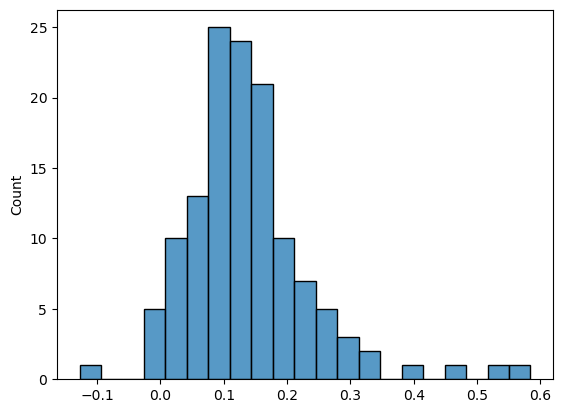

In [33]:
sns.histplot(reliability_best)